# 02 — Расширенный RSA-анализ (Эксперименты 1-3)

Полный анализ иерархической структуры на датасете из 123 слов.

**Эксперименты:**
1. **RSA по слоям** — обученная vs случайная модель + тест перестановок
2. **Асимметрия иерархии** — гиперонимы vs гипонимы (Mann-Whitney U)
3. **Ортогональность направлений** — |cos(d_upper, d_lower)| (Wilcoxon)
**Дополнительные визуализации:**
4. **UMAP-проекция** — 2D-карта семантического пространства
5. **RDM heatmap** — матрица сходства 123×123

В конце ноутбука — улучшенные визуализации.

**Требует:** `outputs/dataset.json` (запустите 01_dataset.ipynb)

## Импорты и настройка среды

In [1]:
import gc
import json
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import torch
from scipy.stats import spearmanr, mannwhitneyu, wilcoxon, gaussian_kde
from transformer_lens import HookedTransformer
import umap

os.makedirs("outputs", exist_ok=True)

# Параметры запуска
MODEL_NAME = "pythia-160m"   # или "pythia-1b"
DEVICE     = "cpu"
DATASET    = "outputs/dataset.json"

print(f"Модель: EleutherAI/{MODEL_NAME}  |  Устройство: {DEVICE}")

/Users/ajratislamow/Desktop/deeplom/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Модель: EleutherAI/pythia-160m  |  Устройство: cpu


## Загрузка датасета и ground-truth матрицы

$$GT[i,j] = \frac{1}{1 + |level_i - level_j|}$$
если одна категория, иначе 0.

In [2]:
def load_dataset(path: str = "outputs/dataset.json") -> tuple:
    with open(path) as f:
        records = json.load(f)
    words    = [r["word"]       for r in records]
    levels   = [r["level"]      for r in records]
    cats     = [r["category"]   for r in records]
    typical  = [r["is_typical"] for r in records]
    return words, levels, cats, typical, records


def build_gt_flat(levels: list, cats: list) -> np.ndarray:
    """Верхний треугольник GT-матрицы как плоский вектор."""
    n  = len(levels)
    gt = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if cats[i] == cats[j]:
                gt[i, j] = 1.0 / (1.0 + abs(levels[i] - levels[j]))
    return gt[np.triu_indices(n, k=1)]


words, levels, cats, typical, records = load_dataset(DATASET)
N = len(words)
gt_flat = build_gt_flat(levels, cats)

print(f"Датасет: {N} слов, {len(set(cats))} категории")
print(f"GT вектор: {len(gt_flat)} пар (верхний треугольник {N}×{N})")

Датасет: 123 слов, 5 категории
GT вектор: 7503 пар (верхний треугольник 123×123)


## Вспомогательные функции

In [3]:
def make_prompt(word: str) -> str:
    return f"The word '{word}' means"


def get_word_token_idx(model: HookedTransformer, prompt: str, word: str) -> int:
    """Индекс последнего токена слова в промпте."""
    tokens = model.to_tokens(prompt)[0]
    raw    = [model.to_string(t.unsqueeze(0)) for t in tokens]
    token_str: list = [s[0] if isinstance(s, list) else s for s in raw]
    word_clean = word.lower().replace(" ", "").replace("_", "")
    for end in range(1, len(token_str)):
        chunk = "".join(token_str[1:end + 1]).lower().replace(" ", "").replace("'", "").replace("_", "")
        if word_clean in chunk:
            return end
    return len(token_str) - 2

In [4]:
def extract_all_layers(model: HookedTransformer, words: list) -> np.ndarray:
    """
    Возвращает [n_layers+1, N, d_model].
    Слой 0 = embedding (resid_pre), 1..n_layers = resid_post.
    """
    n_layers = model.cfg.n_layers
    d_model  = model.cfg.d_model
    n        = len(words)
    acts     = np.zeros((n_layers + 1, n, d_model), dtype=np.float32)

    for wi, word in enumerate(words):
        prompt = make_prompt(word)
        tokens = model.to_tokens(prompt)
        idx    = get_word_token_idx(model, prompt, word)
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens)
        acts[0, wi] = cache["blocks.0.hook_resid_pre"][0, idx].cpu().numpy()
        for l in range(n_layers):
            acts[l + 1, wi] = cache[f"blocks.{l}.hook_resid_post"][0, idx].cpu().numpy()
    return acts

In [5]:
def whiten_pca(X: np.ndarray, k: int = 5) -> np.ndarray:
    """PCA-whitening: центрирование + top-k SVD компоненты × sqrt(N)."""
    X = X - X.mean(axis=0, keepdims=True)
    k = min(k, X.shape[0] - 1, X.shape[1])
    U, _, _ = np.linalg.svd(X, full_matrices=False)
    return U[:, :k] * np.sqrt(X.shape[0])


def cosine_sim(X: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
    Xn    = X / norms
    return Xn @ Xn.T


def rsa_score(X: np.ndarray, gt_flat: np.ndarray) -> float:
    """Spearman ρ между RDM модели и эталонной матрицей."""
    W    = whiten_pca(X, k=5)
    sim  = cosine_sim(W)
    flat = sim[np.triu_indices(len(X), k=1)]
    res  = spearmanr(flat, gt_flat)
    rho  = getattr(res, "statistic", None) or getattr(res, "correlation")
    return float(rho)


def permutation_test_rsa(X: np.ndarray, gt_flat: np.ndarray,
                          n_perm: int = 1000,
                          rng=None) -> tuple:
    """
    Тест перестановок для RSA.
    H0: порядок слов в X случаен (нет структуры).
    Перемешиваем строки X n_perm раз → эмпирическое нулевое распределение ρ.
    Возвращает (observed_rho, p_value).
    """
    if rng is None:
        rng = np.random.default_rng(42)
    n_words  = len(X)
    obs_rho  = rsa_score(X, gt_flat)
    null_rho = np.empty(n_perm)
    for i in range(n_perm):
        perm        = rng.permutation(n_words)
        null_rho[i] = rsa_score(X[perm], gt_flat)
    p_value = float(np.mean(null_rho >= obs_rho))
    return obs_rho, p_value

## Загрузка моделей

Загружаем обученную и случайную версии модели.
Для случайной: `init_weights()` переинициализирует все параметры.

In [6]:
print(f"Загрузка обученной модели {MODEL_NAME} …")
model_t = HookedTransformer.from_pretrained(
    f"EleutherAI/{MODEL_NAME}",
    center_unembed=True, center_writing_weights=True,
    fold_ln=True, device=DEVICE)
model_t.eval()
print(f"  {model_t.cfg.n_layers} слоёв, d_model={model_t.cfg.d_model}")

Загрузка обученной модели pythia-160m …


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model EleutherAI/pythia-160m into HookedTransformer
  12 слоёв, d_model=768


In [7]:
print(f"Загрузка случайной модели {MODEL_NAME} …")
model_r = HookedTransformer.from_pretrained(
    f"EleutherAI/{MODEL_NAME}",
    center_unembed=False, center_writing_weights=False,
    fold_ln=False, device=DEVICE)
model_r.init_weights()
model_r.eval()
print("  Готово (веса переинициализированы).")

Загрузка случайной модели pythia-160m …
Loaded pretrained model EleutherAI/pythia-160m into HookedTransformer
  Готово (веса переинициализированы).


## Извлечение активаций

123 слова × 13 слоёв (embed + 12 трансформерных блоков).
После извлечения выгружаем модели из памяти.

In [8]:
print(f"Извлечение активаций ({N} слов × {model_t.cfg.n_layers + 1} слоёв) …")
print("  Обученная модель …")
acts_t = extract_all_layers(model_t, words)
print(f"  Форма: {acts_t.shape}")

print("  Случайная модель …")
acts_r = extract_all_layers(model_r, words)

del model_t, model_r
gc.collect()
print("Модели выгружены из памяти.")

Извлечение активаций (123 слов × 13 слоёв) …
  Обученная модель …
  Форма: (13, 123, 768)
  Случайная модель …
Модели выгружены из памяти.


## Эксперимент 1: RSA по слоям (trained vs random)

Для каждого слоя:
1. Вычисляем Spearman ρ между RDM модели и GT-матрицей
2. Проводим тест перестановок (1000 итераций) для оценки значимости
3. Строим двухпанельный график: RSA-кривая + -log₁₀(p)

**Пиковый слой** обученной модели определяется автоматически и используется во всех последующих задачах.

In [9]:
def task_full_rsa(acts_trained, acts_random, gt_flat, model_name, out_dir, n_perm=1000):
    """RSA по всем слоям с тестом перестановок. Возвращает пиковый слой."""
    n_layers_plus1 = acts_trained.shape[0]
    rng = np.random.default_rng(42)

    trained_scores, random_scores, p_values = [], [], []
    print(f"  Тест перестановок ({n_perm} × {n_layers_plus1} слоёв)…")
    for l in range(n_layers_plus1):
        rho, pval = permutation_test_rsa(acts_trained[l], gt_flat, n_perm=n_perm, rng=rng)
        trained_scores.append(rho)
        p_values.append(pval)
        random_scores.append(rsa_score(acts_random[l], gt_flat))

    peak_layer = int(np.argmax(trained_scores))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7),
                                    gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
    xs = list(range(n_layers_plus1))

    ax1.plot(xs, trained_scores, "o-", color="#1976D2", linewidth=2,
             label=f"Trained ({model_name})")
    ax1.plot(xs, random_scores,  "s--", color="#EF5350", linewidth=1.5,
             label="Random weights", alpha=0.7)
    ax1.axvline(peak_layer, color="#1976D2", linestyle=":", alpha=0.5,
                label=f"Peak layer {peak_layer}")
    ax1.set_ylabel("Spearman ρ")
    ax1.set_title(f"RSA score per layer — {model_name}  ({acts_trained.shape[1]} words)",
                  fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    sig_colors = ["#43A047" if p < 0.05 else "#EF5350" for p in p_values]
    ax2.bar(xs, [-np.log10(p + 1e-4) for p in p_values], color=sig_colors, alpha=0.85)
    ax2.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, label="p = 0.05")
    ax2.axhline(-np.log10(0.01), color="black", linestyle=":",  linewidth=1, label="p = 0.01")
    ax2.set_ylabel("-log₁₀(p)")
    ax2.set_xlabel("Layer  (0 = embed)")
    ax2.legend(fontsize=8, loc="upper left")
    ax2.grid(True, alpha=0.2)

    slug = model_name.replace("pythia-", "")
    path = f"{out_dir}/ext_rsa_per_layer_{slug}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    df = pd.DataFrame({
        "layer":       xs,
        "rho_trained": trained_scores,
        "rho_random":  random_scores,
        "p_value":     p_values,
        "significant": [p < 0.05 for p in p_values],
    })
    df.to_csv(f"{out_dir}/ext_rsa_per_layer_{slug}.csv", index=False)

    print(f"\n  {'Layer':<7} {'ρ trained':>10} {'ρ random':>10} {'p-value':>9}  sig")
    print(f"  {'-'*46}")
    for _, row in df.iterrows():
        sig = "***" if row.p_value < 0.001 else "**" if row.p_value < 0.01 else \
              "*"   if row.p_value < 0.05  else "n.s."
        lbl = "embed" if row.layer == 0 else f"L{int(row.layer)}"
        print(f"  {lbl:<7} {row.rho_trained:>10.4f} {row.rho_random:>10.4f} "
              f"{row.p_value:>9.4f}  {sig}")
    print(f"\n  Пиковый слой: L{peak_layer}  ρ={trained_scores[peak_layer]:.4f}")
    return peak_layer

  Тест перестановок (1000 × 13 слоёв)…


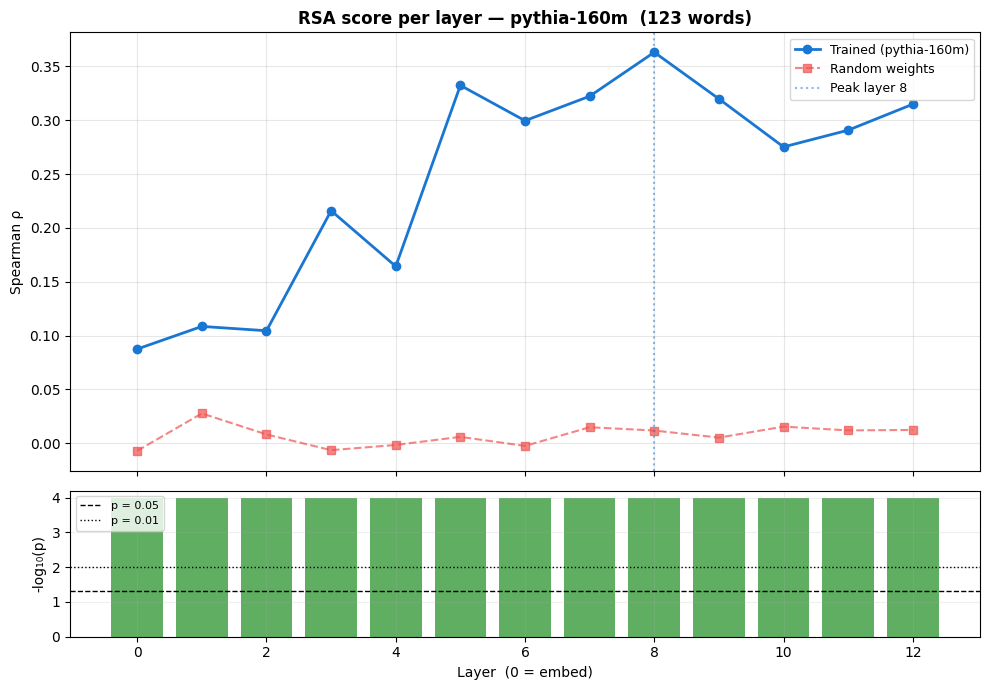


  Layer    ρ trained   ρ random   p-value  sig
  ----------------------------------------------
  embed       0.0876    -0.0070    0.0000  ***
  L1          0.1086     0.0278    0.0000  ***
  L2          0.1046     0.0082    0.0000  ***
  L3          0.2160    -0.0064    0.0000  ***
  L4          0.1643    -0.0015    0.0000  ***
  L5          0.3324     0.0060    0.0000  ***
  L6          0.2996    -0.0024    0.0000  ***
  L7          0.3223     0.0149    0.0000  ***
  L8          0.3632     0.0119    0.0000  ***
  L9          0.3199     0.0053    0.0000  ***
  L10         0.2753     0.0155    0.0000  ***
  L11         0.2908     0.0120    0.0000  ***
  L12         0.3149     0.0124    0.0000  ***

  Пиковый слой: L8  ρ=0.3632


In [10]:
peak_layer = task_full_rsa(acts_t, acts_r, gt_flat, MODEL_NAME, "outputs")

## Эксперимент 2: Асимметрия иерархии

Проверяем, одинаково ли кластеризованы слова разных уровней:
- **Верхний уровень** (avg_level ≤ 2.0): пары типа animal–bird, food–fruit
- **Нижний уровень** (avg_level > 2.0): пары типа sparrow–eagle, hammer–chisel

**Гипотеза:** гиперонимы (широкие категории) должны быть геометрически теснее,
чем гипонимы — дистрибутивная гипотеза включения (Geffet & Dagan, 2005).

**Тест:** Mann-Whitney U (H₁: upper > lower, одностороннее).

In [11]:
def task_asymmetry(acts, levels, cats, peak_layer, model_name, out_dir):
    """Асимметрия: верхние vs нижние пары по косинусному сходству."""
    n = len(levels)
    W   = whiten_pca(acts[peak_layer], k=5)
    sim = cosine_sim(W)

    upper_sims, lower_sims = [], []
    for i in range(n):
        for j in range(i + 1, n):
            if cats[i] != cats[j]:
                continue
            avg_level = (levels[i] + levels[j]) / 2
            s = float(sim[i, j])
            if avg_level <= 2.0:
                upper_sims.append(s)
            else:
                lower_sims.append(s)

    upper_mean = np.mean(upper_sims)
    lower_mean = np.mean(lower_sims)

    stat, pval = mannwhitneyu(upper_sims, lower_sims, alternative="greater")
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.violinplot([upper_sims, lower_sims], positions=[1, 2],
                  showmedians=True, showextrema=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Upper-level pairs\n(L1–L2, hypernyms)",
                        "Lower-level pairs\n(L3–L4, hyponyms)"])
    ax.set_ylabel("Cosine similarity")
    ax.set_title(f"Hierarchy asymmetry — {model_name}  (layer {peak_layer})\n"
                 f"Mann-Whitney U p={pval:.4f} {sig}", fontweight="bold")
    ax.axhline(0, color="grey", linewidth=0.8)
    for pos, val, label in [(1, upper_mean, f"μ={upper_mean:.3f}"),
                             (2, lower_mean, f"μ={lower_mean:.3f}")]:
        ax.text(pos, ax.get_ylim()[0] + 0.02, label, ha="center", fontsize=9, color="navy")

    slug = model_name.replace("pythia-", "")
    path = f"{out_dir}/ext_asymmetry_{slug}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Upper μ={upper_mean:.4f}   Lower μ={lower_mean:.4f}"
          f"   Δ={upper_mean - lower_mean:+.4f}"
          f"   Mann-Whitney p={pval:.4f} {sig}")

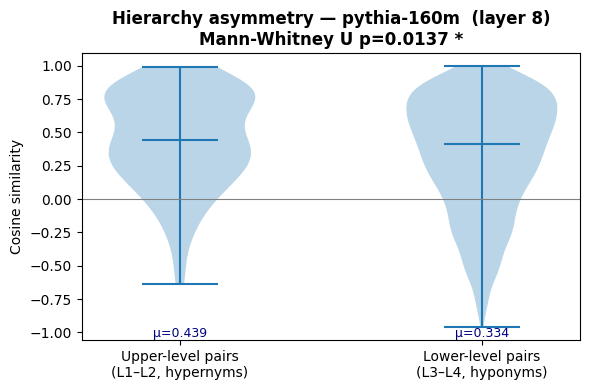

  Upper μ=0.4392   Lower μ=0.3335   Δ=+0.1056   Mann-Whitney p=0.0137 *


In [12]:
task_asymmetry(acts_t, levels, cats, peak_layer, MODEL_NAME, "outputs")

## Эксперимент 3: Ортогональность межуровневых направлений

Для каждого триплета (дедушка G, родитель P, ребёнок C):
```
d_upper = v(P) - v(G)   # направление G → P
d_lower = v(C) - v(P)   # направление P → C
```

Если уровни иерархии кодируются в **ортогональных** подпространствах,
ожидаем `|cos(d_upper, d_lower)| ≈ 0`.

Случайный базовый уровень для d=768: E[|cos θ|] ≈ √(2/πd) ≈ 0.029.

**Важно:** PCA-whitening НЕ применяется к разностным векторам —
cosine измеряется в исходном 768D пространстве.

**Тест:** одновыборочный Wilcoxon signed-rank (H₁: median > 0.029).

In [13]:
def task_orthogonality(acts, levels, cats, records, peak_layer, model_name, out_dir):
    """Косинусное сходство между векторами перехода через уровни иерархии."""
    words_list = [r["word"] for r in records]
    word2idx   = {w: i for i, w in enumerate(words_list)}
    X          = acts[peak_layer].astype(np.float64)

    triplets_data = []
    for r in records:
        cw    = r["word"]
        chain = r["hypernym_chain"]

        parent_word = None
        for ancestor in reversed(chain[:-1]):
            if ancestor in word2idx and ancestor != cw:
                parent_word = ancestor
                break
        if parent_word is None:
            continue

        p_chain_pos = chain.index(parent_word) if parent_word in chain else -1
        gp_word = None
        if p_chain_pos > 0:
            for ancestor in reversed(chain[:p_chain_pos]):
                if ancestor in word2idx and ancestor != parent_word:
                    gp_word = ancestor
                    break
        if gp_word is None:
            continue

        ci  = word2idx[cw]
        pi  = word2idx[parent_word]
        gpi = word2idx[gp_word]

        d_upper = X[pi] - X[gpi]
        d_lower = X[ci] - X[pi]
        n_u = np.linalg.norm(d_upper) + 1e-8
        n_l = np.linalg.norm(d_lower) + 1e-8
        orth_cos = abs(np.dot(d_upper, d_lower) / (n_u * n_l))

        triplets_data.append({
            "grandparent": gp_word, "parent": parent_word, "child": cw,
            "child_level": r["level"], "category": r["category"],
            "orth_cos": orth_cos,
        })

    df = pd.DataFrame(triplets_data)
    slug = model_name.replace("pythia-", "")
    df.to_csv(f"{out_dir}/ext_orthogonality_{slug}.csv", index=False)

    d_model  = acts.shape[-1]
    baseline = math.sqrt(2 / (math.pi * d_model))

    all_cos = df["orth_cos"].values
    w_stat, w_pval = wilcoxon(all_cos - baseline, alternative="greater")
    w_sig = "***" if w_pval < 0.001 else "**" if w_pval < 0.01 else "*" if w_pval < 0.05 else "n.s."

    lvls  = sorted(df["child_level"].unique())
    means = [df[df["child_level"] == l]["orth_cos"].mean() for l in lvls]
    stds  = [df[df["child_level"] == l]["orth_cos"].std()  for l in lvls]
    overall = df["orth_cos"].mean()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar([str(l) for l in lvls], means, yerr=stds, color="#42A5F5",
           alpha=0.85, capsize=4, error_kw={"linewidth": 1.5})
    ax.axhline(baseline, color="red", linestyle="--", linewidth=1,
               label=f"Random baseline √(2/πd) = {baseline:.3f}")
    ax.set_xlabel("Child concept level")
    ax.set_ylabel("|cos(d_upper, d_lower)|  (lower = more orthogonal)")
    ax.set_title(
        f"Cross-level direction orthogonality\n"
        f"{model_name}  (layer {peak_layer})  "
        f"Wilcoxon p={w_pval:.2e} {w_sig}",
        fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 0.8)
    path = f"{out_dir}/ext_orthogonality_{slug}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"  Всего триплетов: {len(df)}")
    print(f"  Overall |cos| = {overall:.4f}  baseline = {baseline:.4f}  "
          f"ratio = {overall/baseline:.1f}×")
    print(f"  Wilcoxon: W={w_stat:.1f}  p={w_pval:.2e} {w_sig}")
    for l, m, s in zip(lvls, means, stds):
        print(f"  L{l}: |cos|={m:.4f} ± {s:.4f}")

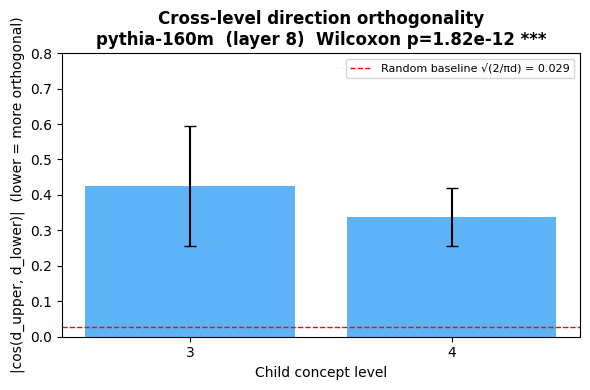

  Всего триплетов: 39
  Overall |cos| = 0.4035  baseline = 0.0288  ratio = 14.0×
  Wilcoxon: W=780.0  p=1.82e-12 ***
  L3: |cos|=0.4258 ± 0.1696
  L4: |cos|=0.3388 ± 0.0818


In [14]:
task_orthogonality(acts_t, levels, cats, records, peak_layer, MODEL_NAME, "outputs")

## Визуализация: UMAP-проекция

2D-проекция семантического пространства на пиковом слое.
Цвет = категория, цифра в подписи = уровень иерархии, ★ = атипичный exemplar.

UMAP с косинусной метрикой лучше сохраняет структуру высокоразмерных данных,
чем PCA, поскольку нелинейно растягивает плотные кластеры.

In [15]:
CAT_COLORS = {
    "animal":    "#4CAF50",
    "vehicle":   "#2196F3",
    "tool":      "#FF9800",
    "food":      "#E91E63",
    "furniture": "#9C27B0",
}

def task_umap(acts, words, levels, cats, typical, peak_layer, model_name, out_dir):
    """2D UMAP-проекция на пиковом слое."""
    X = acts[peak_layer]
    X = X - X.mean(axis=0)

    reducer = umap.UMAP(n_neighbors=10, min_dist=0.3, metric="cosine", random_state=42)
    emb = reducer.fit_transform(X)

    fig, ax = plt.subplots(figsize=(11, 8))
    for cat, color in CAT_COLORS.items():
        mask = [i for i, c in enumerate(cats) if c == cat]
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=color, s=80, alpha=0.8, label=cat, zorder=2)

    for i, (word, lv, typ) in enumerate(zip(words, levels, typical)):
        marker = "★" if not typ else ""
        ax.annotate(f"{word}{marker} ({lv})",
                    (emb[i, 0], emb[i, 1]),
                    fontsize=6.5, ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points")

    cat_handles = [mpatches.Patch(color=c, label=k)
                   for k, c in CAT_COLORS.items() if k in cats]
    ax.legend(handles=cat_handles, fontsize=9, loc="best")
    ax.set_title(f"UMAP — {model_name}  layer {peak_layer}\n"
                 f"★ = atypical exemplar  (N={len(words)})", fontweight="bold")
    ax.axis("off")

    slug = model_name.replace("pythia-", "")
    path = f"{out_dir}/ext_umap_{slug}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Сохранено → {path}")

/Users/ajratislamow/Desktop/deeplom/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


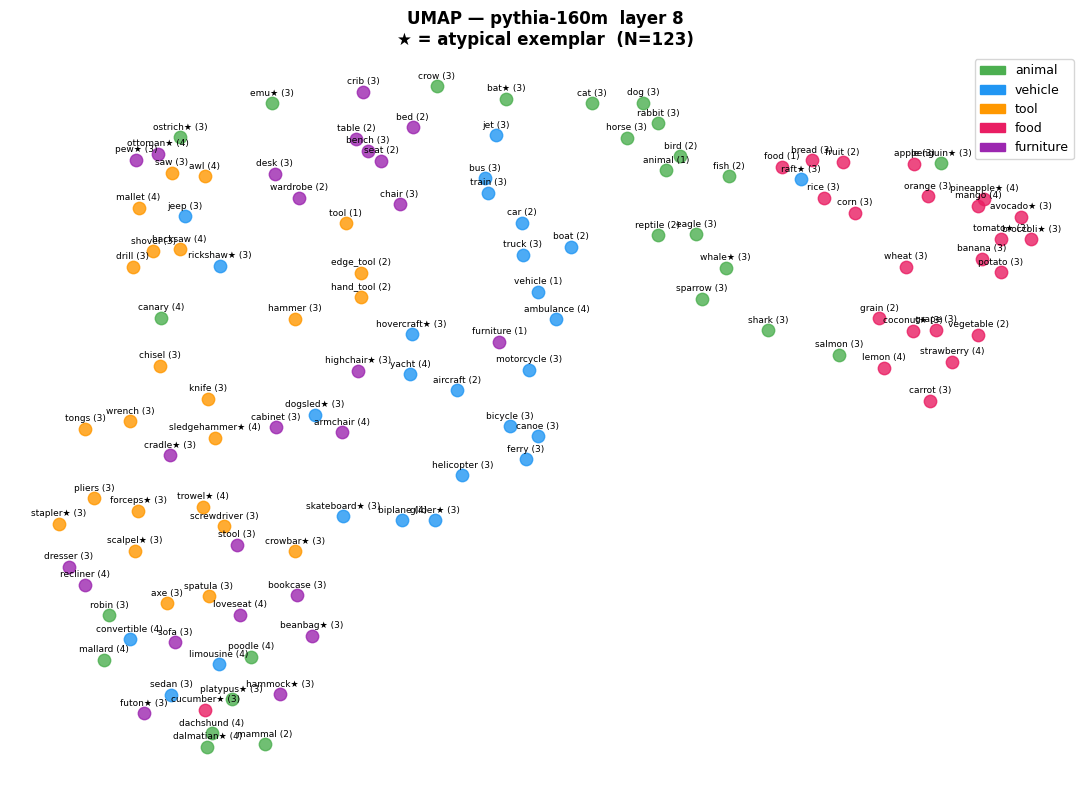

  Сохранено → outputs/ext_umap_160m.png


In [16]:
task_umap(acts_t, words, levels, cats, typical, peak_layer, MODEL_NAME, "outputs")

## Визуализаация: RDM heatmap (123×123)

Матрица косинусных сходств всех 123 слов, отсортированных по категориям.
Видна блоковая структура: блоки на диагонали соответствуют категориям.

In [17]:
def task_rdm_heatmap(acts, words, cats, peak_layer, model_name, out_dir):
    """Большая RDM heatmap 123×123, сортировка по категориям."""
    W   = whiten_pca(acts[peak_layer], k=5)
    sim = cosine_sim(W)

    order  = sorted(range(len(cats)), key=lambda i: (cats[i], words[i]))
    sim_s  = sim[np.ix_(order, order)]
    labels = [f"{words[i]}\n({cats[i][0].upper()})" for i in order]

    mask_diag = np.eye(len(order), dtype=bool)
    off = sim_s[~mask_diag]
    abs_max = max(abs(off.min()), abs(off.max()), 1e-3)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(sim_s, ax=ax, vmin=-abs_max, vmax=abs_max,
                cmap="RdBu_r", xticklabels=labels, yticklabels=labels,
                linewidths=0.2, linecolor="lightgrey",
                cbar_kws={"shrink": 0.6})
    ax.set_title(f"RDM — {model_name}  layer {peak_layer}  ({len(words)} words)",
                 fontweight="bold", fontsize=13)
    ax.tick_params(axis="both", labelsize=6)
    slug = model_name.replace("pythia-", "")
    path = f"{out_dir}/ext_rdm_{slug}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Сохранено → {path}")

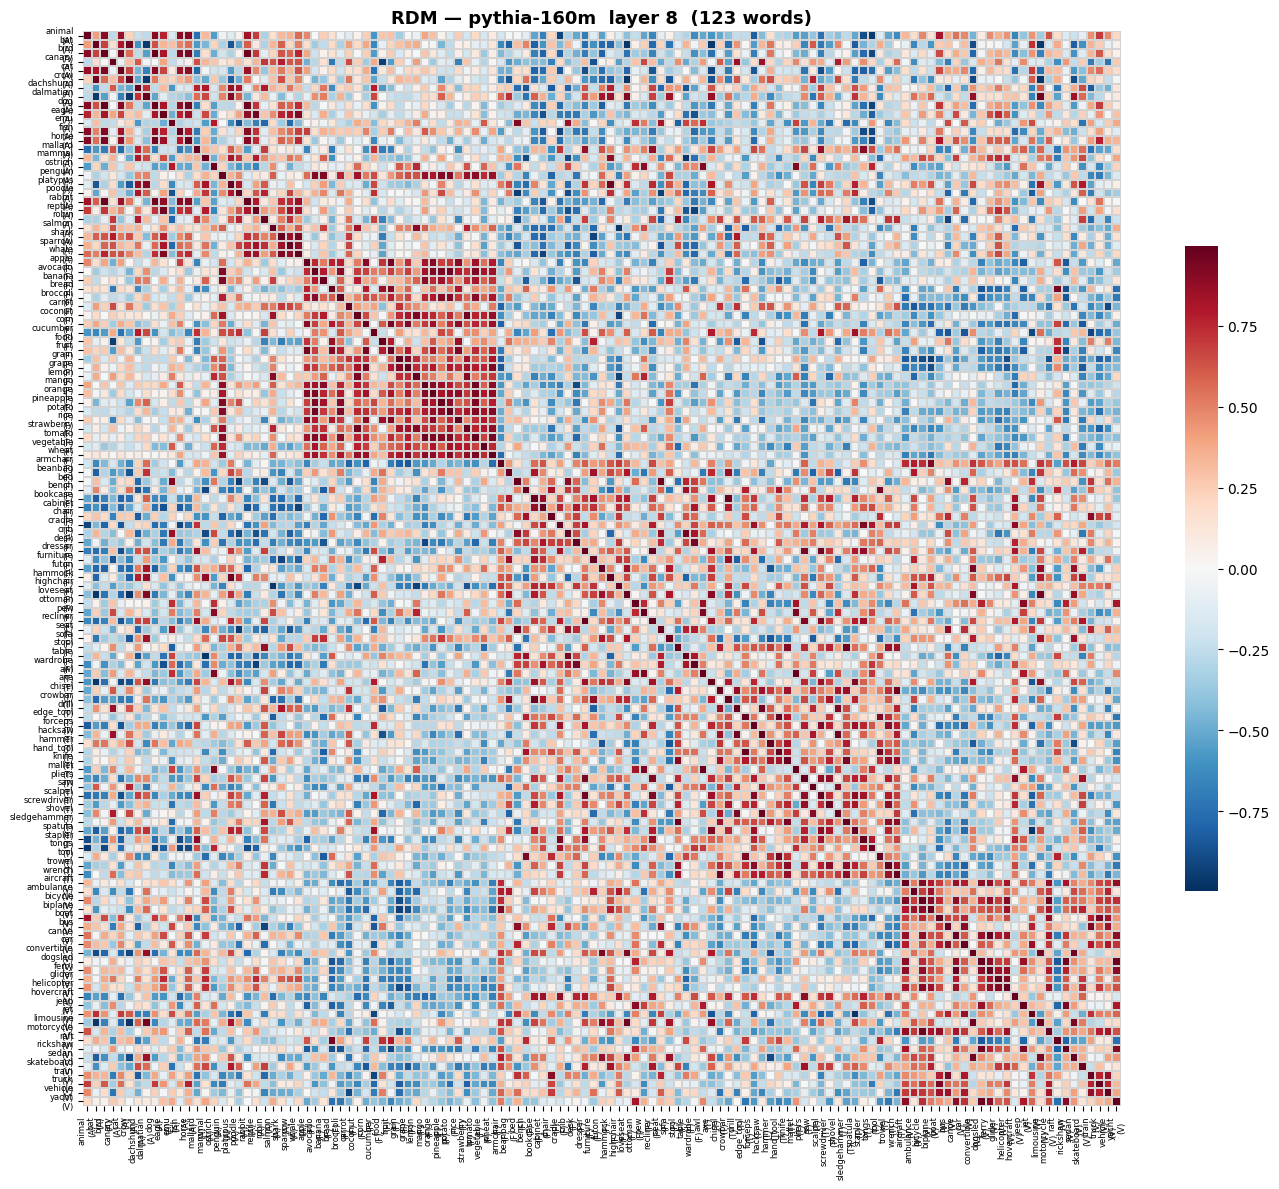

  Сохранено → outputs/ext_rdm_160m.png


In [18]:
task_rdm_heatmap(acts_t, words, cats, peak_layer, MODEL_NAME, "outputs")

---

## Улучшенные визуализации

Следующие ячейки содержат улучшенные версии ключевых графиков:
- **RDM случайной модели** — для сравнения с обученной
- **GT heatmap** — эталонная матрица WordNet
- **KDE-plot асимметрии** — overlapping KDE вместо violin (лучше читается)
- **Ортогональность** — бар-чарт с правильным baseline 0.029 (old: 0.5)

### RDM случайной модели (L8)

Для сравнения с обученной моделью: одни и те же 123 слова, тот же слой,
но случайно инициализированные веса.

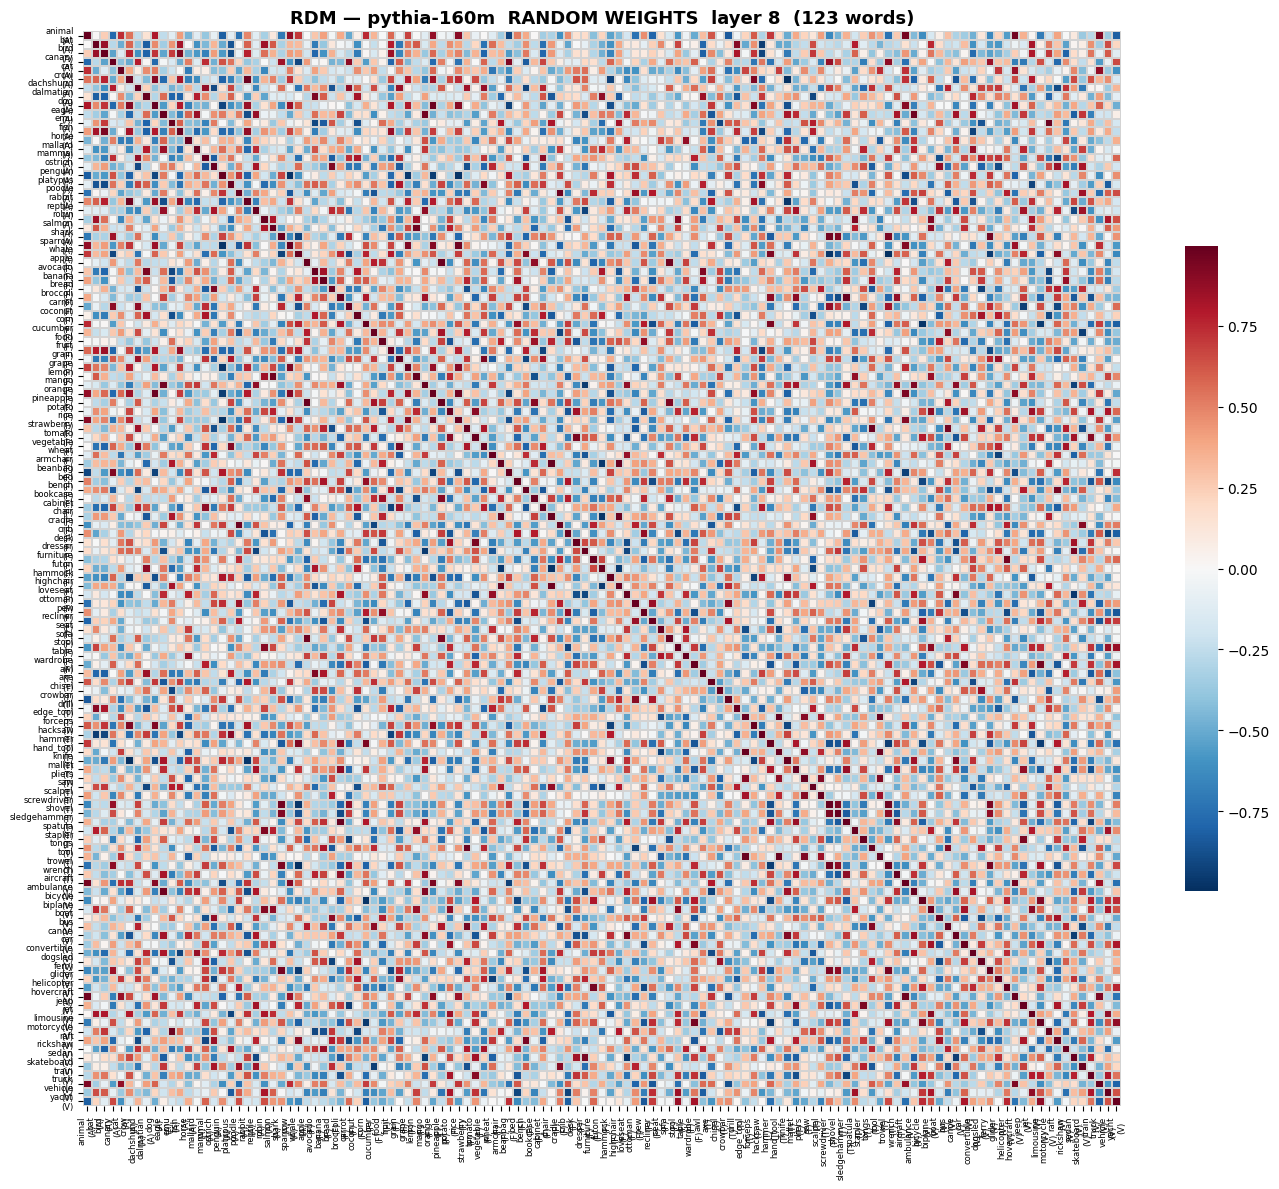

Сохранено → outputs/ext_rdm_random_160m.png


In [19]:
PEAK_LAYER_FIXED = 8  # фиксированный слой для replot-анализа

W_r   = whiten_pca(acts_r[PEAK_LAYER_FIXED], k=5)
sim_r = cosine_sim(W_r)

order  = sorted(range(len(cats)), key=lambda i: (cats[i], words[i]))
sim_rs = sim_r[np.ix_(order, order)]
labels = [f"{words[i]}\n({cats[i][0].upper()})" for i in order]

mask_diag = np.eye(len(order), dtype=bool)
off_r     = sim_rs[~mask_diag]
abs_max_r = max(abs(off_r.min()), abs(off_r.max()), 1e-3)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(sim_rs, ax=ax, vmin=-abs_max_r, vmax=abs_max_r,
            cmap="RdBu_r", xticklabels=labels, yticklabels=labels,
            linewidths=0.2, linecolor="lightgrey", cbar_kws={"shrink": 0.6})
ax.set_title(f"RDM — {MODEL_NAME}  RANDOM WEIGHTS  layer {PEAK_LAYER_FIXED}  ({N} words)",
             fontweight="bold", fontsize=13)
ax.tick_params(axis="both", labelsize=6)
fig.tight_layout()
fig.savefig("outputs/ext_rdm_random_160m.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено → outputs/ext_rdm_random_160m.png")

### GT heatmap — эталонная матрица WordNet

Визуализация ground-truth матрицы. Яркие блоки на диагонали = одна категория,
интенсивность = близость уровней.

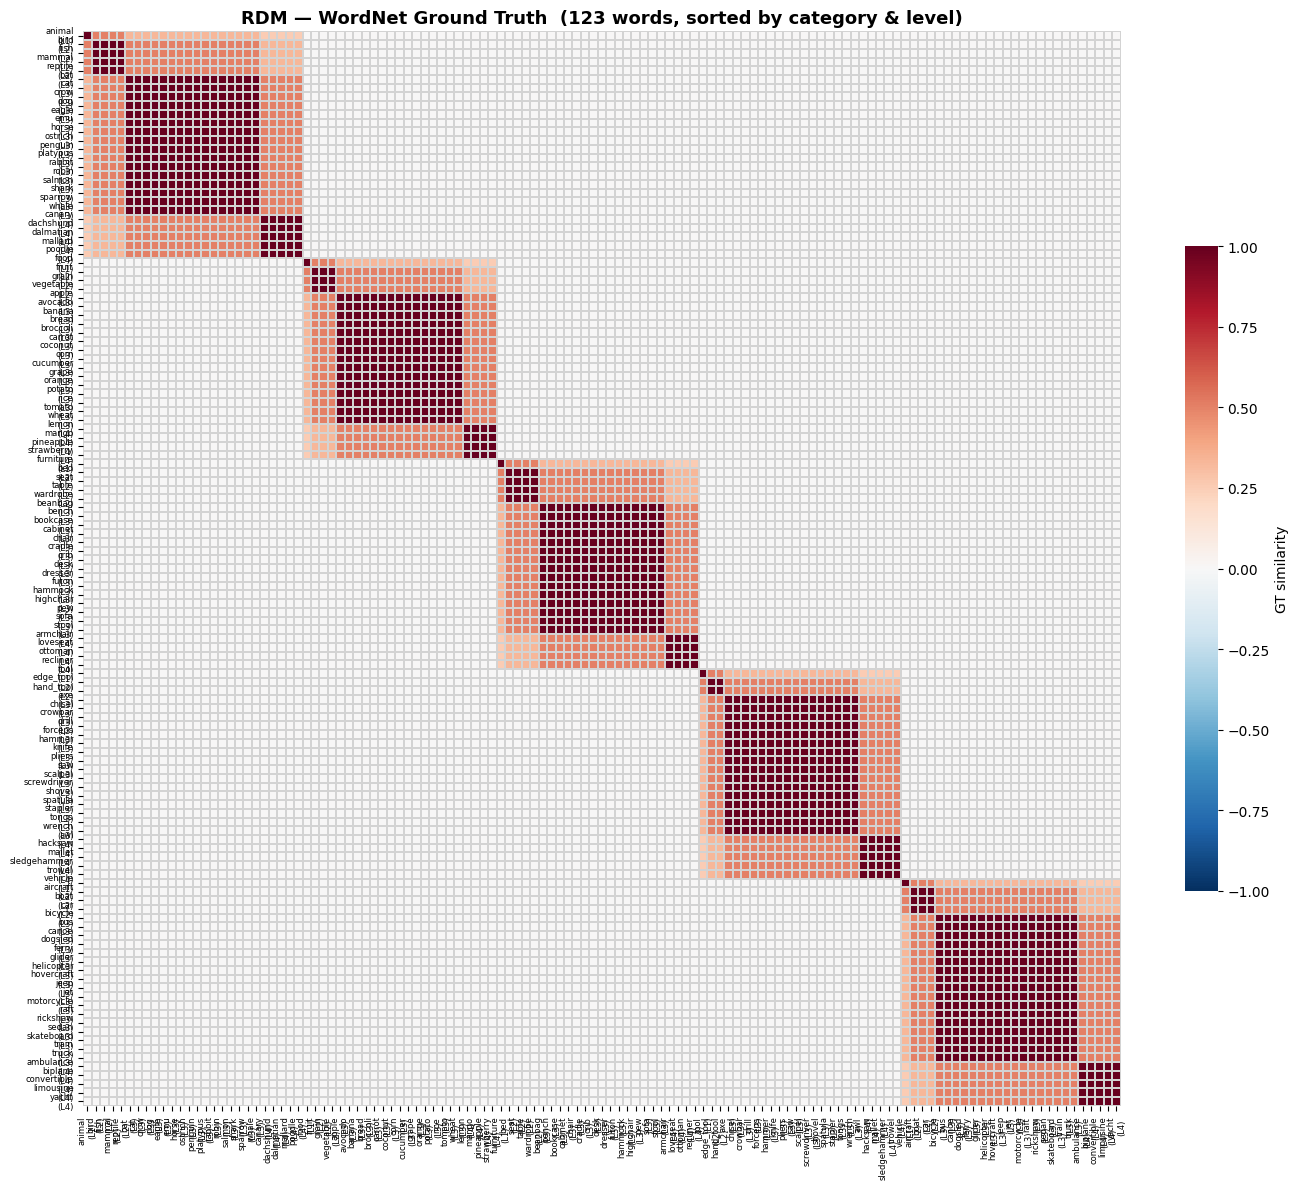

Сохранено → outputs/ext_rdm_gt.png


In [20]:
n = len(words)
gt_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if cats[i] == cats[j]:
            gt_matrix[i, j] = 1.0 / (1.0 + abs(levels[i] - levels[j]))

order_gt = sorted(range(n), key=lambda i: (cats[i], levels[i], words[i]))
gt_s     = gt_matrix[np.ix_(order_gt, order_gt)]
labels_gt = [f"{words[i]}\n(L{levels[i]})" for i in order_gt]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(gt_s, ax=ax, vmin=-1, vmax=1,
            cmap="RdBu_r", xticklabels=labels_gt, yticklabels=labels_gt,
            linewidths=0.2, linecolor="lightgrey",
            cbar_kws={"shrink": 0.6, "label": "GT similarity"})
ax.set_title(f"RDM — WordNet Ground Truth  ({n} words, sorted by category & level)",
             fontweight="bold", fontsize=13)
ax.tick_params(axis="both", labelsize=6)
fig.tight_layout()
fig.savefig("outputs/ext_rdm_gt.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено → outputs/ext_rdm_gt.png")

### Улучшенный plot асимметрии: overlapping KDE

KDE-plot с rug-plot и скобкой значимости лучше передаёт форму распределений,
чем violin-plot из предыдущей задачи.

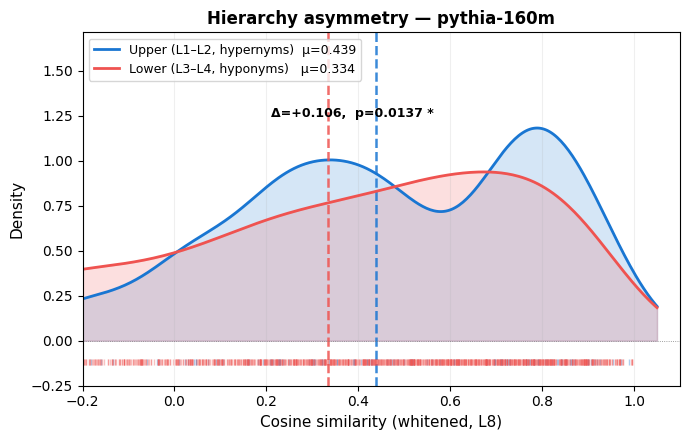

Сохранено → outputs/ext_asymmetry_160m.png


In [21]:
W_peak = whiten_pca(acts_t[peak_layer], k=5)
sim_peak = cosine_sim(W_peak)

upper_sims_k, lower_sims_k = [], []
for i in range(N):
    for j in range(i + 1, N):
        if cats[i] != cats[j]:
            continue
        avg_level = (levels[i] + levels[j]) / 2
        s = float(sim_peak[i, j])
        (upper_sims_k if avg_level <= 2.0 else lower_sims_k).append(s)

upper_arr = np.array(upper_sims_k)
lower_arr = np.array(lower_sims_k)

stat_k, pval_k = mannwhitneyu(upper_arr, lower_arr, alternative="greater")
sig_k = "***" if pval_k < 0.001 else "**" if pval_k < 0.01 else "*" if pval_k < 0.05 else "n.s."

COL_UPPER = "#1976D2"
COL_LOWER = "#EF5350"
xs = np.linspace(-0.2, 1.05, 300)

fig, ax = plt.subplots(figsize=(7, 4.5))
for sims, col, label in [
    (upper_arr, COL_UPPER, f"Upper (L1–L2, hypernyms)  μ={upper_arr.mean():.3f}"),
    (lower_arr, COL_LOWER, f"Lower (L3–L4, hyponyms)   μ={lower_arr.mean():.3f}"),
]:
    kde = gaussian_kde(sims, bw_method=0.25)
    ys  = kde(xs)
    ax.fill_between(xs, ys, alpha=0.18, color=col)
    ax.plot(xs, ys, color=col, linewidth=2, label=label)
    ax.axvline(sims.mean(), color=col, linewidth=1.8, linestyle="--", alpha=0.85)
    ax.plot(sims, np.full_like(sims, -0.12), "|", color=col, alpha=0.35, markersize=5)

# скобка значимости
mu_u = upper_arr.mean()
mu_l = lower_arr.mean()
kde_u = gaussian_kde(upper_arr, bw_method=0.25)
kde_l = gaussian_kde(lower_arr, bw_method=0.25)
y_peak_kde = max(kde_u(xs).max(), kde_l(xs).max())
y_bracket = y_peak_kde * 1.08
ax.text((mu_u + mu_l) / 2, y_bracket - y_peak_kde * 0.04,
        f"Δ={mu_u - mu_l:+.3f},  p={pval_k:.4f} {sig_k}",
        ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel(f"Cosine similarity (whitened, L{peak_layer})", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(f"Hierarchy asymmetry — {MODEL_NAME}", fontweight="bold", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(-0.2, 1.1)
ax.set_ylim(-0.25, y_peak_kde * 1.45)
ax.axhline(0, color="grey", linewidth=0.6, linestyle=":")
ax.grid(True, alpha=0.2, axis="x")

slug = MODEL_NAME.replace("pythia-", "")
fig.tight_layout()
fig.savefig(f"outputs/ext_asymmetry_{slug}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Сохранено → outputs/ext_asymmetry_{slug}.png")

### Улучшенный plot ортогональности

Перегенерирует график из сохранённого CSV с правильным baseline = 0.029.


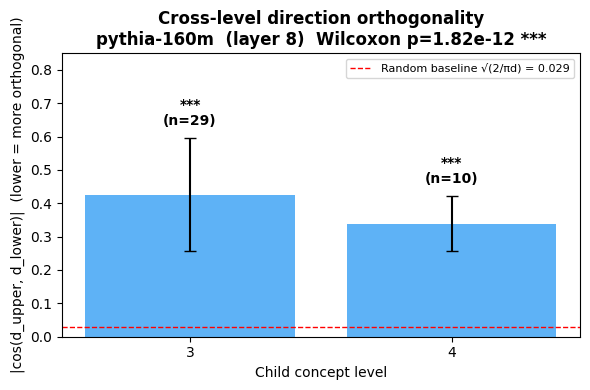

Сохранено → outputs/ext_orthogonality_160m.png
Overall |cos| = 0.4035  baseline = 0.0288  ratio = 14.0×
Wilcoxon: W=780.0  p=1.82e-12 ***


In [22]:
slug = MODEL_NAME.replace("pythia-", "")
csvpath = f"outputs/ext_orthogonality_{slug}.csv"

df_orth = pd.read_csv(csvpath)
all_cos  = df_orth["orth_cos"].values
d_model  = acts_t.shape[-1]  # 768 для 160m
baseline = math.sqrt(2 / (math.pi * d_model))

w_stat_r, w_pval_r = wilcoxon(all_cos - baseline, alternative="greater")
w_sig_r = "***" if w_pval_r < 0.001 else "**" if w_pval_r < 0.01 else "*" if w_pval_r < 0.05 else "n.s."

lvls_r  = sorted(df_orth["child_level"].unique())
means_r = [df_orth[df_orth["child_level"] == l]["orth_cos"].mean() for l in lvls_r]
stds_r  = [df_orth[df_orth["child_level"] == l]["orth_cos"].std()  for l in lvls_r]
ns_r    = [len(df_orth[df_orth["child_level"] == l]) for l in lvls_r]

# per-group Wilcoxon
per_sig_r = []
for l in lvls_r:
    vals = df_orth[df_orth["child_level"] == l]["orth_cos"].values
    _, p = wilcoxon(vals - baseline, alternative="greater")
    per_sig_r.append("***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s.")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([str(l) for l in lvls_r], means_r, yerr=stds_r, color="#42A5F5",
              alpha=0.85, capsize=4, error_kw={"linewidth": 1.5})
ax.axhline(baseline, color="red", linestyle="--", linewidth=1,
           label=f"Random baseline √(2/πd) = {baseline:.3f}")

for bar, mean, std, sig, n in zip(bars, means_r, stds_r, per_sig_r, ns_r):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + std + 0.03, f"{sig}\n(n={n})",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Child concept level")
ax.set_ylabel("|cos(d_upper, d_lower)|  (lower = more orthogonal)")
ax.set_title(
    f"Cross-level direction orthogonality\n"
    f"{MODEL_NAME}  (layer {peak_layer})  "
    f"Wilcoxon p={w_pval_r:.2e} {w_sig_r}",
    fontweight="bold")
ax.legend(fontsize=8)
ax.set_ylim(0, 0.85)
fig.tight_layout()
fig.savefig(f"outputs/ext_orthogonality_{slug}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Сохранено → outputs/ext_orthogonality_{slug}.png")
print(f"Overall |cos| = {all_cos.mean():.4f}  baseline = {baseline:.4f}  "
      f"ratio = {all_cos.mean()/baseline:.1f}×")
print(f"Wilcoxon: W={w_stat_r:.1f}  p={w_pval_r:.2e} {w_sig_r}")